In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
print("doun")

doun


In [88]:
customers = pd.read_csv("./Customers.csv", encoding="latin1",sep=';')
location = pd.read_csv("./Location.csv",sep=';')
orders = pd.read_csv("./Orders.csv",sep=';')
product = pd.read_csv("./Products.csv", encoding="latin1")

In [89]:
customers.head(5)

,Customer ID,Customer Name
0,AA-10315,Alex Avila
1,AA-10375,Allen Armold
2,AA-10480,Andrew Allen
3,AA-10645,Anna Andreadi
4,AB-10015,Aaron Bergman


In [90]:
location.head(5)

,Postal Code,City,State,Region,Country/Region
0,76106.0,Fort Worth,Texas,Central,United States
1,53711.0,Madison,Wisconsin,Central,United States
2,68025.0,Fremont,Nebraska,Central,United States
3,77095.0,Houston,Texas,Central,United States
4,75080.0,Richardson,Texas,Central,United States


In [91]:
orders.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Postal Code,Product ID,Sales,Quantity,Discount,Profit
0,1,CA-2022-152156,08/11/2022,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-BO-10001798,261.9600,2,0.00,41.9136
1,2,CA-2022-152156,08/11/2022,11/11/2022,Second Class,CG-12520,Consumer,42420,FUR-CH-10000454,731.9400,3,0.00,219.5820
2,3,CA-2022-138688,12/06/2022,16/06/2022,Second Class,DV-13045,Corporate,90036,OFF-LA-10000240,14.6200,2,0.00,6.8714
3,4,US-2021-108966,11/10/2021,18/10/2021,Standard Class,SO-20335,Consumer,33311,FUR-TA-10000577,957.5775,5,0.45,-383.0310
4,5,US-2021-108966,11/10/2021,18/10/2021,Standard Class,SO-20335,Consumer,33311,OFF-ST-10000760,22.3680,2,0.20,2.5164


In [92]:
product.head(5)

,Product ID,Category,Sub-Category,Product Name,Unnamed: 4,Unnamed: 5
0,FUR-BO-10000112,Furniture,Bookcases,Bush Birmingham Collection Bookcase,NaN,NaN
1,FUR-BO-10000330,NaN,NaN,NaN,NaN,NaN
2,FUR-BO-10000362,Furniture,Bookcases,Sauder Inglewood Library Bookcases,NaN,NaN
3,FUR-BO-10000468,Furniture,Bookcases,O'Sullivan 2-Shelf Heavy-Duty Bookcases,NaN,NaN
4,FUR-BO-10000711,Furniture,Bookcases,Hon Metal Bookcases,NaN,NaN


In [93]:
customers.shape

(793, 2)

In [94]:
customers.isnull().sum()

Customer ID      0
Customer Name    0
dtype: int64

In [95]:
customers["Customer ID"].is_unique

True

In [96]:
customers["Customer Name"].duplicated().sum()

np.int64(0)

In [97]:
customers.columns = (
    customers.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [98]:
customers.columns

Index(['customer_id', 'customer_name'], dtype='object')

In [99]:
customers["customer_name"] = customers["customer_name"].str.strip().str.title()


In [100]:
location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 632 entries, 0 to 631
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Postal Code     631 non-null    float64
 1   City            632 non-null    object 
 2   State           632 non-null    object 
 3   Region          632 non-null    object 
 4   Country/Region  632 non-null    object 
dtypes: float64(1), object(4)
memory usage: 24.8+ KB


In [101]:
location.shape

(632, 5)

In [102]:
location.isnull().sum()

Postal Code       1
City              0
State             0
Region            0
Country/Region    0
dtype: int64

In [103]:
location['Postal Code'].value_counts()

Postal Code
92024.0    2
53132.0    1
98208.0    1
87124.0    1
60540.0    1
          ..
83301.0    1
92672.0    1
94568.0    1
93405.0    1
77041.0    1
Name: count, Length: 630, dtype: int64

In [104]:
location['Postal Code'].unique()

array([76106., 53711., 68025., 77095., 75080., 77041., 60540., 55122.,
       48185., 47150., 60610., 49201., 77070., 60623., 55901., 55407.,
       55106., 60462., 50322., 61701., 64055., 53132., 73034., 78207.,
       77036., 62521., 75051., 75220., 48601., 48227., 55044., 77506.,
       48180., 78745., 78550., 62301., 61604., 48187., 47201., 73071.,
       60068., 79109., 77340., 64118., 48234., 60653., 54302., 78041.,
       75217., 48126., 48307., 60505., 76017., 75081., 75701., 48205.,
       60201., 48183., 55016., 50315., 68104., 53209., 75043., 78664.,
       52601., 65109., 63376., 61107., 78521., 47374., 46350., 48911.,
       48073., 52402., 75061., 75019., 54915., 75002., 79907., 76051.,
       75007., 60076., 75023., 46203., 53142., 66062., 74133., 74403.,
       46614., 76248., 65807., 73120., 79424., 65203., 56560., 75150.,
       77840., 63116., 76903., 48146., 47362., 48640., 57103., 47905.,
       60126., 46544., 60098., 76117., 60090., 75034., 53186., 78415.,
      

In [105]:
location.columns = (
    location.columns
    .str.strip()
    .str.lower()
    .str.replace("/", "_")
    .str.replace(" ", "_")
)


In [106]:
location.columns

Index(['postal_code', 'city', 'state', 'region', 'country_region'], dtype='object')

In [107]:
location.duplicated().sum()

np.int64(0)

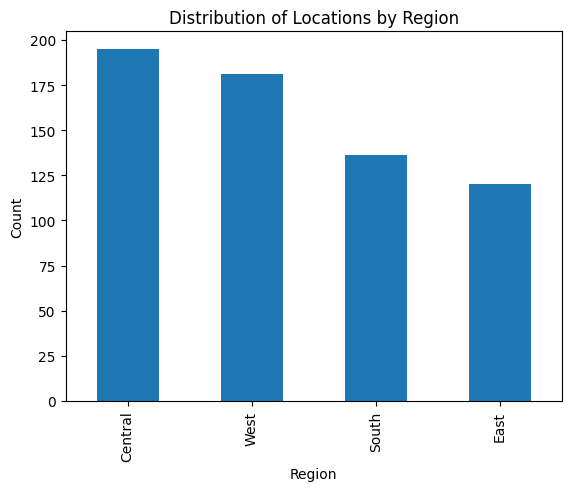

In [108]:
location["region"].value_counts().plot(kind="bar")
plt.title("Distribution of Locations by Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.show()


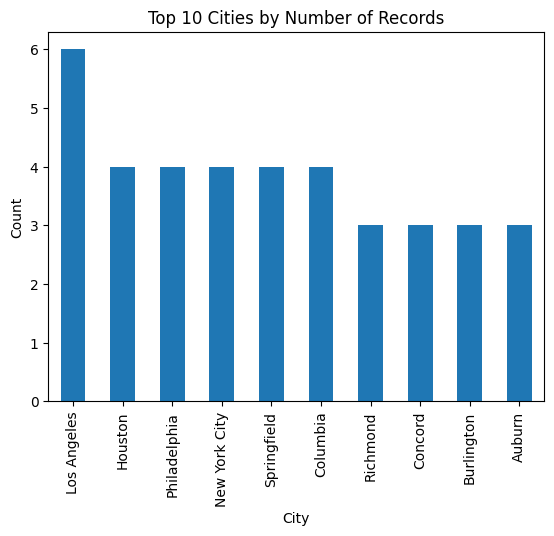

In [109]:
location["city"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Cities by Number of Records")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

In [110]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Row ID       9994 non-null   int64  
 1   Order ID     9994 non-null   object 
 2   Order Date   9994 non-null   object 
 3   Ship Date    9994 non-null   object 
 4   Ship Mode    9994 non-null   object 
 5   Customer ID  9994 non-null   object 
 6   Segment      9994 non-null   object 
 7   Postal Code  9994 non-null   int64  
 8   Product ID   9994 non-null   object 
 9   Sales        9994 non-null   float64
 10  Quantity     9994 non-null   int64  
 11  Discount     9994 non-null   float64
 12  Profit       9994 non-null   float64
dtypes: float64(3), int64(3), object(7)
memory usage: 1015.1+ KB


In [111]:
orders.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55231.117070,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32023.901458,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [112]:
orders.columns = (
    orders.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [113]:
orders.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'segment', 'postal_code', 'product_id', 'sales',
       'quantity', 'discount', 'profit'],
      dtype='object')

In [114]:
orders.drop_duplicates(inplace=True)

In [115]:
orders.value_counts().sum()

np.int64(9994)

In [116]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    dayfirst=True
)


In [117]:
orders["ship_date"] = pd.to_datetime(
    orders["ship_date"],
    dayfirst=True
)

In [118]:
orders[["order_date", "ship_date"]].dtypes


order_date    datetime64[ns]
ship_date     datetime64[ns]
dtype: object

In [ ]:
Q1 = orders['sales'].quantile(0.25)
Q3 = orders['sales'].quantile(0.75)
IQR = Q3 - Q1
IQR

np.float64(192.66)

In [ ]:
outliers = orders[(orders['sales'] < (Q1 - 1.5 * IQR)) | (orders['sales'] > (Q3 + 1.5 * IQR))]
print(f"number of outlier defined: {len(outliers)}")

number of outlier defined: 1167


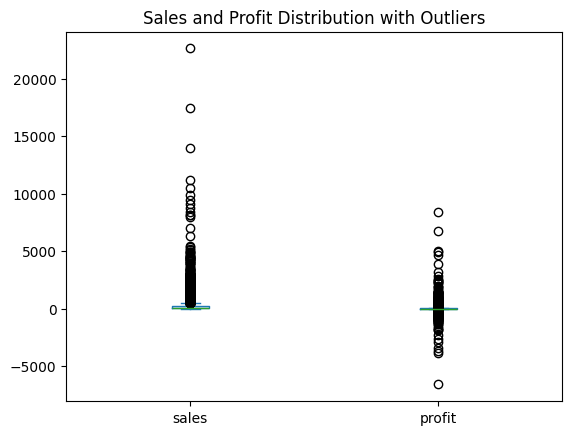

In [121]:
orders[["sales", "profit"]].plot(kind="box")
plt.title("Sales and Profit Distribution with Outliers")
plt.show()


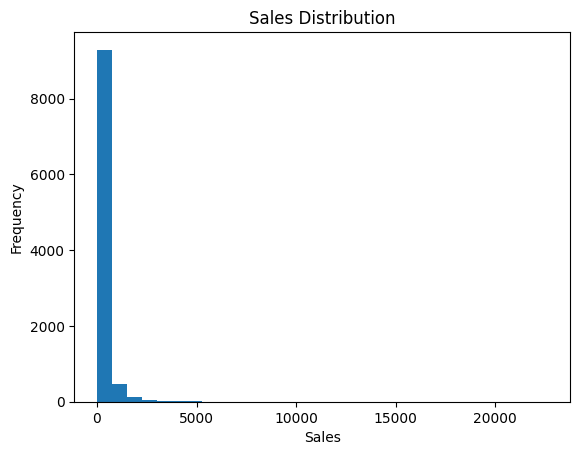

In [122]:
orders["sales"].plot(kind="hist", bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


In [123]:
orders["sales"].median()

np.float64(54.489999999999995)

In [124]:
orders["profit"].mean()

np.float64(28.65689630778467)

In [125]:
orders["ship_days"] = (orders["ship_date"] - orders["order_date"]).dt.days

In [126]:
orders["ship_days"].describe()


count    9994.000000
mean        3.958075
std         1.747937
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: ship_days, dtype: float64

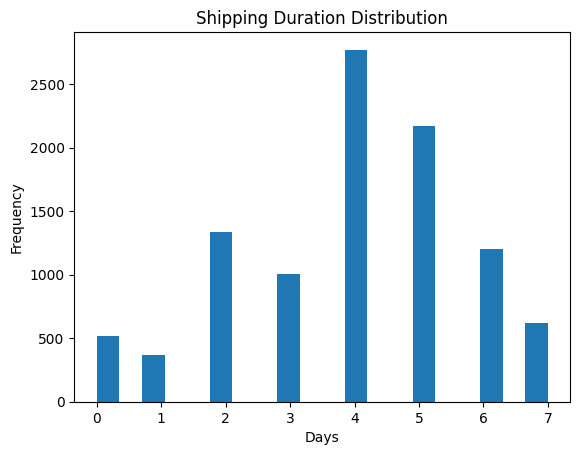

In [127]:
orders["ship_days"].plot(kind="hist", bins=20)
plt.title("Shipping Duration Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()


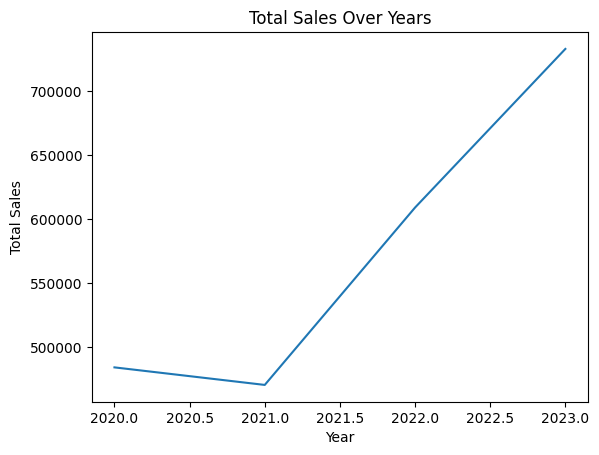

In [128]:
orders.groupby(orders["order_date"].dt.year)["sales"].sum().plot(kind="line")
plt.title("Total Sales Over Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()




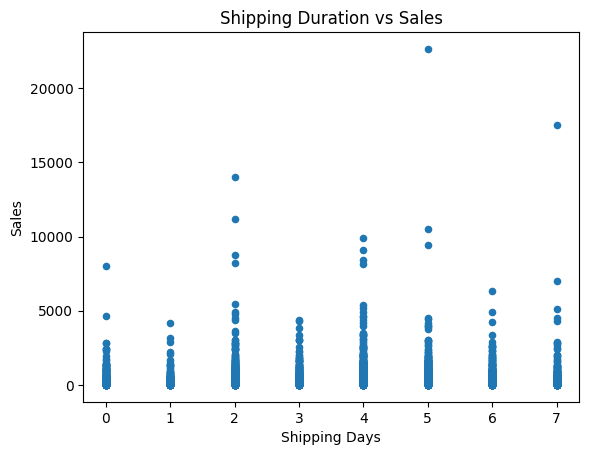

In [129]:
orders.plot(kind="scatter", x="ship_days", y="sales")
plt.title("Shipping Duration vs Sales")
plt.xlabel("Shipping Days")
plt.ylabel("Sales")
plt.show()


In [130]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1894 entries, 0 to 1893
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Product ID    1894 non-null   object
 1   Category      1893 non-null   object
 2   Sub-Category  1893 non-null   object
 3   Product Name  1893 non-null   object
 4   Unnamed: 4    4 non-null      object
 5   Unnamed: 5    1 non-null      object
dtypes: object(6)
memory usage: 88.9+ KB


In [131]:
product.isnull().sum()

Product ID         0
Category           1
Sub-Category       1
Product Name       1
Unnamed: 4      1890
Unnamed: 5      1893
dtype: int64

In [132]:
product.columns = (
    product.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


In [133]:
product= product.drop(columns=["unnamed:_4","unnamed:_5"])

In [134]:
product.columns

Index(['product_id', 'category', 'sub-category', 'product_name'], dtype='object')

In [135]:
product.rename(columns={"sub-category":"sub_category"},inplace=True)

In [136]:
product.columns

Index(['product_id', 'category', 'sub_category', 'product_name'], dtype='object')

In [137]:
product.dropna(inplace=True)

In [138]:
product.duplicated().sum()

np.int64(0)

In [139]:
product.isnull().sum()

product_id      0
category        0
sub_category    0
product_name    0
dtype: int64

In [141]:
final_df = orders.merge(customers, on='customer_id', how='left') \
                 .merge(location, on='postal_code', how='left') \
                 .merge(product, on='product_id', how='left')

In [142]:
final_df.head(5)

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,segment,postal_code,product_id,sales,...,profit,ship_days,customer_name,city,state,region,country_region,category,sub_category,product_name
0,1,CA-2022-152156,2022-11-08,2022-11-11,Second Class,CG-12520,Consumer,42420,FUR-BO-10001798,261.9600,...,41.9136,3,Claire Gute,Henderson,Kentucky,South,United States,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,2,CA-2022-152156,2022-11-08,2022-11-11,Second Class,CG-12520,Consumer,42420,FUR-CH-10000454,731.9400,...,219.5820,3,Claire Gute,Henderson,Kentucky,South,United States,Furniture,Chairs,Hon Deluxe Fabric Upholstered Stacking Chairs
2,3,CA-2022-138688,2022-06-12,2022-06-16,Second Class,DV-13045,Corporate,90036,OFF-LA-10000240,14.6200,...,6.8714,4,Darrin Van Huff,Los Angeles,California,West,United States,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,4,US-2021-108966,2021-10-11,2021-10-18,Standard Class,SO-20335,Consumer,33311,FUR-TA-10000577,957.5775,...,-383.0310,7,Sean O'Donnell,Fort Lauderdale,Florida,South,United States,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,5,US-2021-108966,2021-10-11,2021-10-18,Standard Class,SO-20335,Consumer,33311,OFF-ST-10000760,22.3680,...,2.5164,7,Sean O'Donnell,Fort Lauderdale,Florida,South,United States,Office Supplies,Storage,Eldon Fold 'N Roll Cart System


In [144]:
final_df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'segment', 'postal_code', 'product_id', 'sales',
       'quantity', 'discount', 'profit', 'ship_days', 'customer_name', 'city',
       'state', 'region', 'country_region', 'category', 'sub_category',
       'product_name'],
      dtype='object')

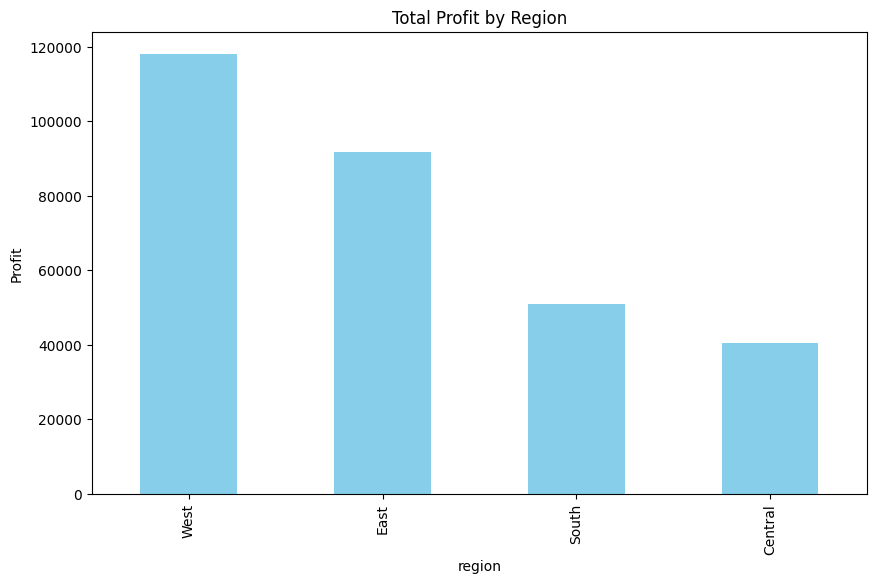

In [145]:
# 4. استخراج الرؤى (Insights) - مثال: الأرباح حسب المنطقة
plt.figure(figsize=(10,6))
region_profit = final_df.groupby('region')['profit'].sum().sort_values(ascending=False)
region_profit.plot(kind='bar', color='skyblue')
plt.title('Total Profit by Region')
plt.ylabel('Profit')
plt.show()

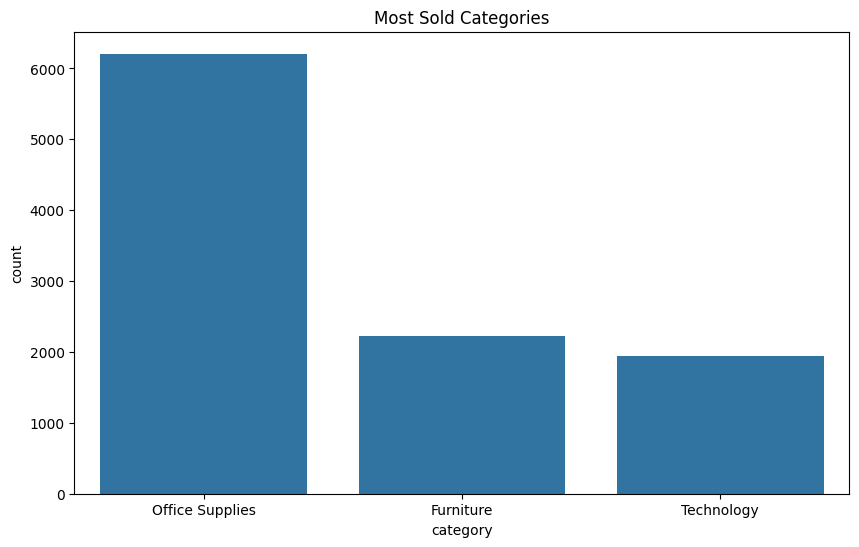

In [146]:
# 5. تحليل الفئات الأكثر مبيعاً
plt.figure(figsize=(10,6))
sns.countplot(data=final_df, x='category', order=final_df['category'].value_counts().index)
plt.title('Most Sold Categories')
plt.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_1760\129001364.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ship_mode', y='ship_days', data=final_df, palette='viridis')


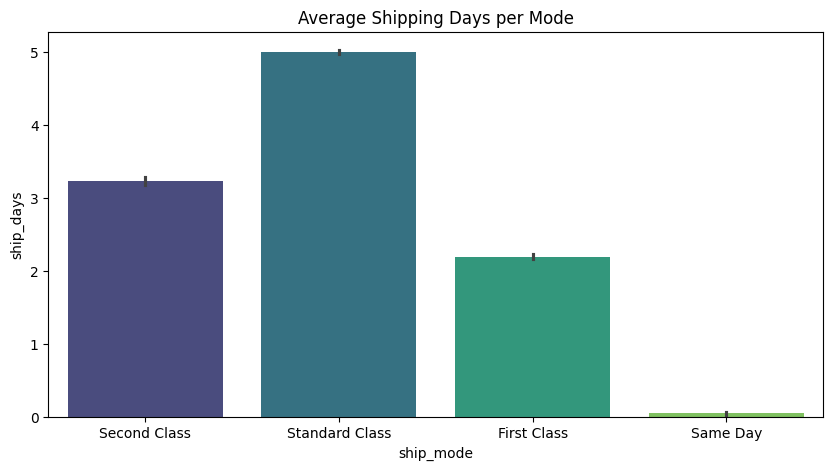

In [147]:
plt.figure(figsize=(10,5))
sns.barplot(x='ship_mode', y='ship_days', data=final_df, palette='viridis')
plt.title('Average Shipping Days per Mode')
plt.show()

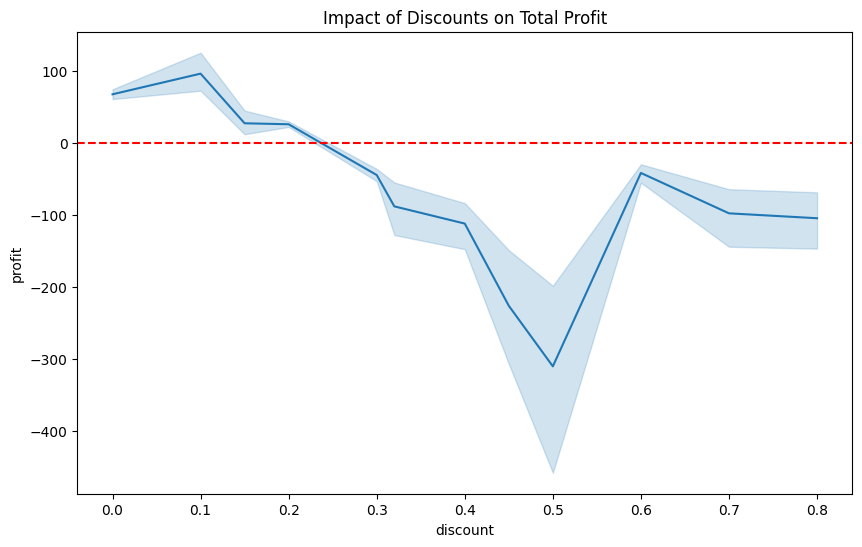

In [148]:
plt.figure(figsize=(10,6))
sns.lineplot(x='discount', y='profit', data=final_df)
plt.axhline(0, color='red', linestyle='--')
plt.title('Impact of Discounts on Total Profit')
plt.show()

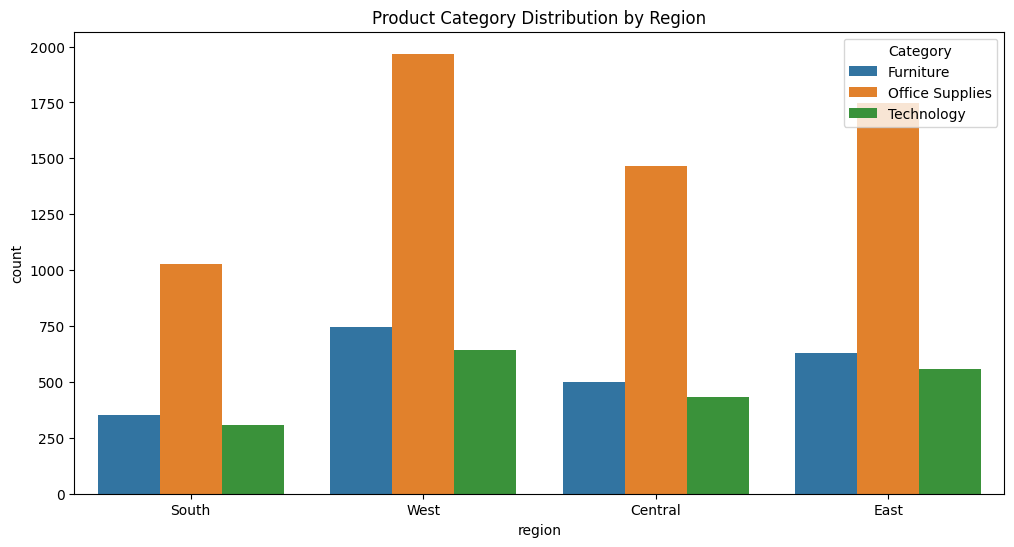

In [149]:
plt.figure(figsize=(12,6))
sns.countplot(x='region', hue='category', data=final_df)
plt.title('Product Category Distribution by Region')
plt.legend(title='Category', loc='upper right')
plt.show()

In [153]:
min_limit = -2000
max_limit = 5000

outliers_profit = final_df[(final_df['profit'] < min_limit) | (final_df['profit'] > max_limit)]

print(f"Number of outlier records detected in profit: {len(outliers_profit)}")

Number of outlier records detected in profit: 0


In [152]:
final_df = final_df[(final_df['profit'] >= min_limit) & (final_df['profit'] <= max_limit)]

print("process completed successfully")

process completed successfully


In [158]:
min_limit = -2000
max_limit = 5000

outliers_ship_days = final_df[(final_df['ship_days'] < min_limit) | (final_df['ship_days'] > max_limit)]

print(f"Number of outlier records detected in ship_days: {len(outliers_ship_days)}")

Number of outlier records detected in ship_days: 0


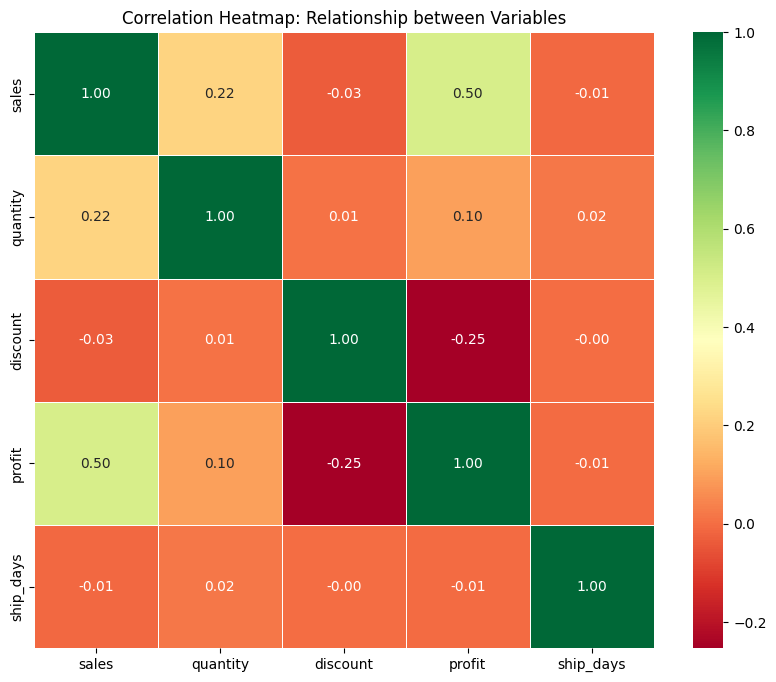

In [156]:
# 1. اختيار الأعمدة الرقمية فقط للتحليل
numerical_columns = final_df[['sales', 'quantity', 'discount', 'profit', 'ship_days']]

# 2. حساب معامل الارتباط (Correlation)
corr_matrix = numerical_columns.corr()

# 3. رسم الهيتماب
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap: Relationship between Variables')
plt.show()

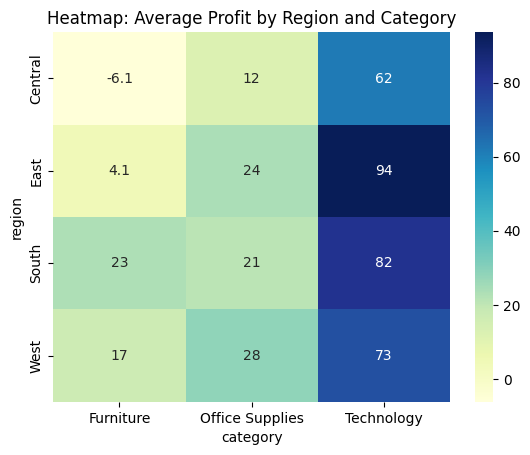

In [157]:
# رسم هيتماب يوضح متوسط الأرباح لكل منطقة وكل فئة منتجات
pivot_table = final_df.pivot_table(index='region', columns='category', values='profit', aggfunc='mean')
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu')
plt.title('Heatmap: Average Profit by Region and Category')
plt.show()